<a href="https://colab.research.google.com/github/Saoudyahya/Dictionary-learning./blob/main/dictionary_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


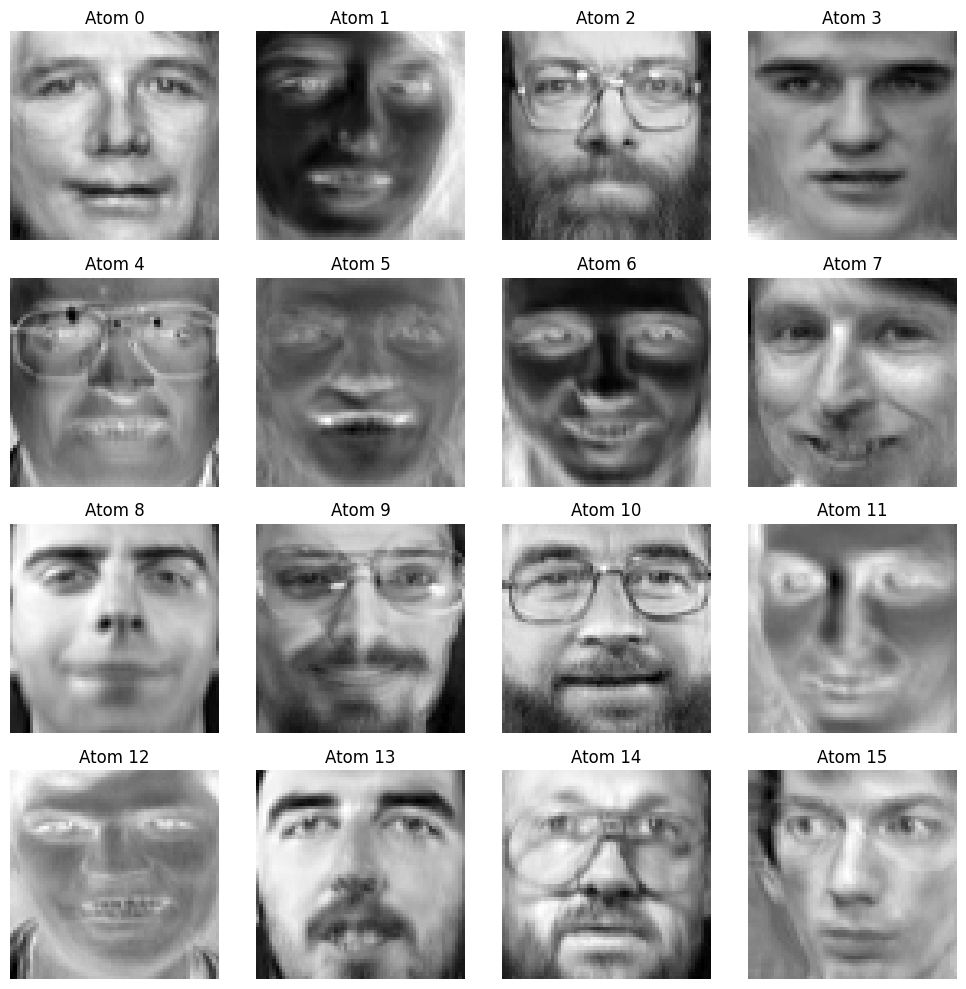

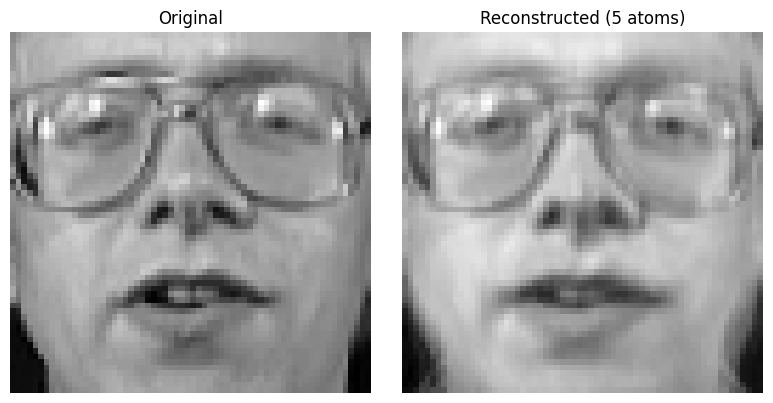

In [1]:
import numpy as np
from sklearn.decomposition import DictionaryLearning
from sklearn.datasets import fetch_olivetti_faces
from matplotlib import pyplot as plt

# Load face dataset
faces = fetch_olivetti_faces()
X = faces.data

# Learn dictionary with 100 atoms
n_components = 100
dict_learner = DictionaryLearning(n_components=n_components,
                                 transform_algorithm='omp',
                                 transform_n_nonzero_coefs=5,
                                 max_iter=1000,
                                 random_state=42)

# Fit the dictionary
dictionary = dict_learner.fit(X).components_

# Display some dictionary atoms (as images)
n_atoms = 16  # Show 16 atoms
plt.figure(figsize=(10, 10))
for i, atom in enumerate(dictionary[:n_atoms]):
    plt.subplot(4, 4, i + 1)
    plt.imshow(atom.reshape(64, 64), cmap=plt.cm.gray)
    plt.title(f"Atom {i}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Use the dictionary to get sparse representation of a sample face
sample_face = X[10:11]  # Select one face
code = dict_learner.transform(sample_face)

# Reconstruct the face using only the non-zero coefficients
# (typically 5 coefficients as specified in transform_n_nonzero_coefs)
reconstructed_face = np.dot(code, dictionary)

# Display original and reconstructed
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_face.reshape(64, 64), cmap=plt.cm.gray)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_face.reshape(64, 64), cmap=plt.cm.gray)
plt.title("Reconstructed (5 atoms)")
plt.axis('off')
plt.tight_layout()
plt.show()